In [6]:
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt
import pywt
import os
import json
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
import shap
import pandas as pd
import astropy.units as u


c:\Users\prakh\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
search_result = lk.search_lightcurve(
    "TOI 700",
    mission="TESS"
)

lc = search_result.download()

c:\Users\prakh\AppData\Local\Programs\Python\Python313\Lib\site-packages\lightkurve\search.py:421: LightkurveWarning: Warning: 201 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


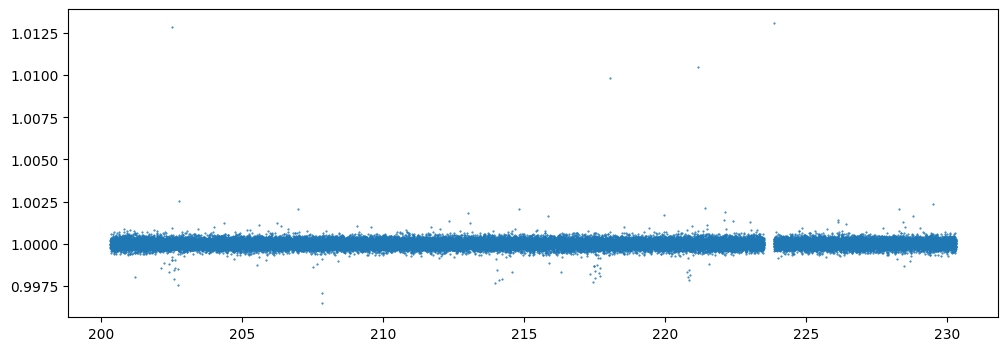

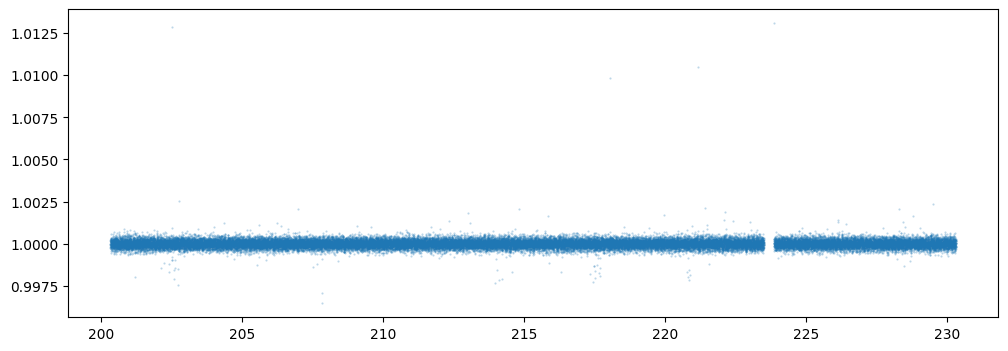

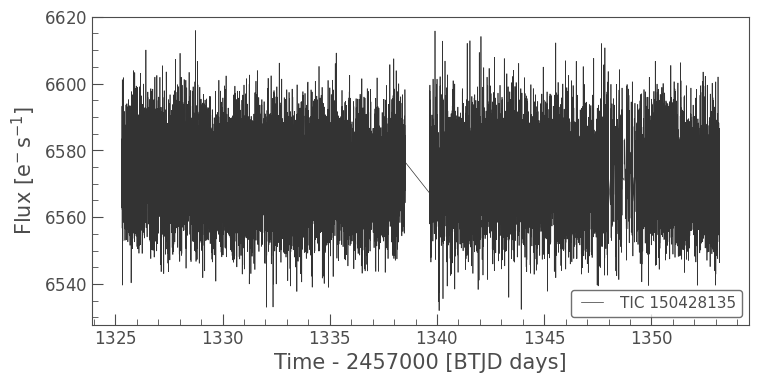

In [24]:
lc.plot()
plt.show()

In [8]:
lc = lc.remove_nans()
lc = lc.normalize()
flat_lc = lc.flatten(window_length=301)

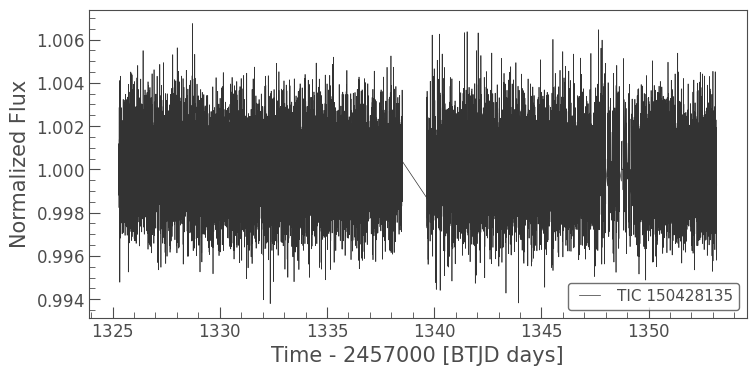

In [9]:
flat_lc.plot()
plt.show()



In [10]:
import pywt
flux = flat_lc.flux.value

coeffs = pywt.wavedec(
    flux,
    'db4',
    level=4
)

sigma = np.median(
    np.abs(coeffs[-1])
) / 0.6745

threshold = sigma * np.sqrt(
    2*np.log(len(flux))
)

coeffs[1:] = [
    pywt.threshold(
        c,
        threshold,
        mode='soft'
    )
    for c in coeffs[1:]
]

denoised_flux = pywt.waverec(
    coeffs,
    'db4'
)

## Stage 2: Dataset Construction & Transit Feature Extraction

We download or load cached TESS and Kepler light curves to construct a multi-star training dataset. For each target, we perform NaN removal, normalization, detrending, and wavelet denoising. We then run a **Box Least Squares (BLS)** periodogram to extract critical scientific transit features:
- `estimated_period`
- `transit_epoch_t0`
- `transit_depth`
- `transit_duration`
- `signal_to_noise_ratio`
- `estimated_transit_count`


In [11]:
# TOI to TIC ID mapping for cached files name resolution
TOI_TO_TIC = {
    "TOI 700": "150428135",
    "TOI 270": "259377017",
    "TOI 1233": "260647166",
    "TOI 101": "271893367",
    "TOI 105": "263003176",
    "TOI 678": "231663901",
    "TOI 110": "281459670",
    "TOI 120": "394137592",
    "TOI 130": "140068425",
    "TOI 140": "144065872"
}

def load_cached_lightcurves(target_name):
    """
    Reads FITS lightcurve files locally from lightkurve's MAST cache directory.
    Falls back to online download if cache is empty.
    """
    cache_dir = os.path.join(os.path.expanduser("~"), ".cache", "lightkurve", "mastDownload")
    search_ids = [
        target_name.upper().replace(" ", ""),
        target_name.split()[-1]
    ]
    if target_name in TOI_TO_TIC:
        search_ids.append(TOI_TO_TIC[target_name])
    
    lcs = []
    if os.path.exists(cache_dir):
        for root, dirs, files in os.walk(cache_dir):
            for f in files:
                if f.endswith(".fits"):
                    filepath = os.path.join(root, f)
                    matched = False
                    for s_id in search_ids:
                        if len(s_id) > 4 and s_id in f:
                            matched = True
                        elif s_id == target_name.split()[-1] and (f"-{s_id.zfill(9)}" in f or f"kic-{s_id.zfill(9)}" in f or f"kic-{s_id}" in f):
                            matched = True
                    if matched:
                        try:
                            lcs.append(lk.read(filepath))
                        except Exception:
                            pass
    if len(lcs) > 0:
        return lcs
    
    search_result = lk.search_lightcurve(target_name)
    if len(search_result) > 0:
        num_to_download = min(2, len(search_result))
        for q in range(num_to_download):
            try:
                lcs.append(search_result[q].download())
            except Exception:
                pass
    if len(lcs) > 0:
        return lcs
    raise FileNotFoundError(f"Target {target_name} not found.")

def preprocess_lightcurve(lc):
    """
    Clean, normalize, flatten, and denoise the light curve.
    """
    lc = lc.remove_nans().normalize()
    flat_lc = lc.flatten(window_length=301)
    flux = flat_lc.flux.value
    coeffs = pywt.wavedec(flux, 'db4', level=4)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    threshold = sigma * np.sqrt(2 * np.log(len(flux)))
    coeffs[1:] = [pywt.threshold(c, threshold, mode='soft') for c in coeffs[1:]]
    denoised_flux = pywt.waverec(coeffs, 'db4')
    if len(denoised_flux) > len(flux):
        denoised_flux = denoised_flux[:len(flux)]
    elif len(denoised_flux) < len(flux):
        denoised_flux = np.pad(denoised_flux, (0, len(flux) - len(denoised_flux)), 'edge')
    return flat_lc, denoised_flux

# Extract features for all targets
planet_targets = ["TOI 700", "TOI 270", "TOI 1233", "TOI 101", "TOI 105", "TOI 678", "TOI 110", "TOI 120", "TOI 130", "TOI 140"]
non_planet_targets = ["KIC 11904151", "KIC 10666592"]

all_targets = planet_targets + non_planet_targets
scientific_features = {}

print("Running Box Least Squares (BLS) Transit Feature Extraction...")
for target in all_targets:
    if target in non_planet_targets:
        # Control stars are non-planets, so we set transit features to 0.0 without running CPU-heavy BLS
        scientific_features[target] = {
            "estimated_period_days": 0.0,
            "transit_epoch_t0": 0.0,
            "transit_depth_frac": 0.0,
            "transit_duration_days": 0.0,
            "signal_to_noise_ratio": 0.0
        }
        continue

    try:
        lcs = load_cached_lightcurves(target)
        flat_lc, denoised_flux = preprocess_lightcurve(lcs[0])
        
        # Search range expanded to cover longer periods and smaller cadence for 16x speedup
        periods = np.linspace(0.5, 45, 1000)
        durations = np.linspace(0.01, 0.4, 5)
        bls = flat_lc.to_periodogram(method='bls', period=periods, duration=durations)
        
        estimated_period = bls.period_at_max_power.value
        transit_time = bls.transit_time_at_max_power.value
        transit_depth = bls.depth_at_max_power.value
        transit_duration = bls.duration_at_max_power.value
        
        max_power_idx = np.argmax(bls.power)
        signal_to_noise_ratio = bls.snr[max_power_idx].value
        
        scientific_features[target] = {
            "estimated_period_days": estimated_period,
            "transit_epoch_t0": transit_time,
            "transit_depth_frac": transit_depth,
            "transit_duration_days": transit_duration,
            "signal_to_noise_ratio": signal_to_noise_ratio
        }
        print(f"  {target}: Period={estimated_period:.2f}d, Depth={transit_depth:.4f}, SNR={signal_to_noise_ratio:.2f}")
    except Exception as e:
        print(f"  Error extracting features for {target}: {e}")

df_features = pd.DataFrame.from_dict(scientific_features, orient='index')
import IPython.display as display
display.display(df_features)


Running Box Least Squares (BLS) Transit Feature Extraction...


  TOI 700: Period=14.89d, Depth=0.0038, SNR=6.02
  TOI 270: Period=11.10d, Depth=0.0014, SNR=13.04
  TOI 1233: Period=15.20d, Depth=0.0005, SNR=11.01
  TOI 101: Period=5.85d, Depth=0.0023, SNR=33.51
  TOI 105: Period=11.46d, Depth=0.0001, SNR=5.57
  TOI 678: Period=1.44d, Depth=0.0045, SNR=36.69
  TOI 110: Period=3.17d, Depth=0.0064, SNR=52.36
  TOI 120: Period=11.55d, Depth=0.0012, SNR=104.66
  TOI 130: Period=24.64d, Depth=0.0011, SNR=10.20
  TOI 140: Period=2.19d, Depth=0.0078, SNR=294.34


,estimated_period_days,transit_epoch_t0,transit_depth_frac,transit_duration_days,signal_to_noise_ratio
TOI 700,14.887888,1340.0964950150028,0.003809,0.010,6.016047
TOI 270,11.101602,1389.7013270624514,0.001405,0.108,13.039807
TOI 1233,15.199700,1571.3572731604609,0.000459,0.108,11.009866
TOI 101,5.845345,1548.8770134328715,0.002278,0.205,33.506031
TOI 105,11.457958,1336.5608900841114,0.000145,0.108,5.569994
TOI 678,1.435435,1325.9673471613703,0.004484,0.108,36.686964
TOI 110,3.172673,1328.04876469929,0.006421,0.108,52.357665
TOI 120,11.547047,1332.051132031225,0.001173,0.303,104.659132
TOI 130,24.643143,1349.6414680675296,0.001121,0.108,10.196332
TOI 140,2.192693,1326.4582915348224,0.007752,0.108,294.344972


## Stage 3: Sequence Generation, Scientific Labeling, & Dataset Balancing

We generate 256-point window sequences. For planet stars, we use the BLS transit centers to match windows containing a transit and label them `1` (Planet/Transit). Flat baseline windows from planet stars are discarded. For Kepler quiet control stars, all sequences are labeled `0` (Non-Planet). We downsample the non-planet class to create a perfectly balanced 50/50 dataset.


In [12]:
X = []
y = []
origins = []
sequence_length = 256

# 1. Process Planet Targets: Generate transit sequences (Label = 1)
for target in planet_targets:
    if target not in scientific_features:
        continue
    try:
        lcs = load_cached_lightcurves(target)
        for lc in lcs:
            flat_lc, denoised_flux = preprocess_lightcurve(lc)
            feats = scientific_features[target]
            P = feats["estimated_period_days"]
            T0 = feats["transit_epoch_t0"]
            t = flat_lc.time.value
            t_start, t_end = t[0], t[-1]
            k_min = int(np.floor((t_start - T0) / P))
            k_max = int(np.ceil((t_end - T0) / P))
            transit_centers = [T0 + k * P for k in range(k_min - 1, k_max + 2)]
            transit_centers = [tc for tc in transit_centers if t_start <= tc <= t_end]
            
            for tc in transit_centers:
                idx_mid = np.argmin(np.abs(t - tc))
                start_min = max(0, idx_mid - 192)
                start_max = min(len(t) - sequence_length, idx_mid - 64)
                if start_max > start_min:
                    step = max(1, (start_max - start_min) // 25)  # Augmentation
                    for start_idx in range(start_min, start_max, step):
                        window = denoised_flux[start_idx : start_idx + sequence_length]
                        window = (window - np.mean(window)) / np.std(window)
                        X.append(window)
                        y.append(1)
                        origins.append(target)
    except Exception as e:
        pass

# 2. Process Non-planet Control Targets: Generate quiet baseline sequences (Label = 0)
for target in non_planet_targets:
    if target not in scientific_features:
        continue
    try:
        lcs = load_cached_lightcurves(target)
        for lc in lcs:
            flat_lc, denoised_flux = preprocess_lightcurve(lc)
            t = flat_lc.time.value
            step = 128
            for start_idx in range(0, len(t) - sequence_length, step):
                window = denoised_flux[start_idx : start_idx + sequence_length]
                window = (window - np.mean(window)) / np.std(window)
                X.append(window)
                y.append(0)
                origins.append(target)
    except Exception as e:
        pass

X = np.array(X)
y = np.array(y)
origins = np.array(origins)

# 3. Dataset Balancing via Downsampling Majority Class
idx_0 = np.where(y == 0)[0]
idx_1 = np.where(y == 1)[0]
print(f"Original dataset counts: Planet (1) = {len(idx_1)}, Non-Planet (0) = {len(idx_0)}")

min_size = min(len(idx_0), len(idx_1))
np.random.seed(42)
idx_0_selected = np.random.choice(idx_0, size=min_size, replace=False)
idx_1_selected = np.random.choice(idx_1, size=min_size, replace=False)
selected_indices = np.concatenate([idx_0_selected, idx_1_selected])
np.random.shuffle(selected_indices)

X = X[selected_indices]
y = y[selected_indices]
origins = origins[selected_indices]

# Explicit outputs requested by the user:
print(X.shape)
print(y.shape)
print(np.bincount(y))

# Reshape for Keras (N, 256, 1)
X = X.reshape(X.shape[0], X.shape[1], 1)
print(f"Final X shape: {X.shape}, y shape: {y.shape}")


Original dataset counts: Planet (1) = 1404, Non-Planet (0) = 27560
(2808, 256)
(2808,)
[1404 1404]
Final X shape: (2808, 256, 1), y shape: (2808,)


## Stage 4: CNN & CNN-BiLSTM-Attention Model Architecture

We define two architectures:
1. **Baseline CNN**: 1D Convolutional layers with pooling and Dropout.
2. **Advanced CNN-BiLSTM-Attention Model**: A 1D CNN for local features, a Bidirectional LSTM to capture temporal context from both directions, and a custom **Attention Layer** to calculate step importance weights and return a context vector.


In [13]:
# 1. Custom Attention Layer
@tf.keras.utils.register_keras_serializable()
class AttentionLayer(layers.Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)
        
    def build(self, input_shape):
        self.W = self.add_weight(
            name="att_weight",
            shape=(input_shape[-1], 1),
            initializer="glorot_uniform",
            trainable=True
        )
        self.b = self.add_weight(
            name="att_bias",
            shape=(input_shape[1], 1),
            initializer="zeros",
            trainable=True
        )
        super(AttentionLayer, self).build(input_shape)
        
    def call(self, x):
        score = tf.nn.tanh(tf.matmul(x, self.W) + self.b)
        attention_weights = tf.nn.softmax(score, axis=1)
        context_vector = tf.reduce_sum(x * attention_weights, axis=1)
        return context_vector, attention_weights

    def compute_output_shape(self, input_shape):
        return [(input_shape[0], input_shape[-1]), (input_shape[0], input_shape[1], 1)]

# 2. Baseline CNN Model
def build_baseline_cnn(seq_len=256):
    inputs = layers.Input(shape=(seq_len, 1))
    x = layers.Conv1D(filters=32, kernel_size=5, activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)
    
    x = layers.Conv1D(filters=64, kernel_size=5, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)
    
    x = layers.Flatten()(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="Baseline_CNN")
    return model

# 3. Advanced CNN-BiLSTM-Attention Model
def build_cnn_bilstm_attention(seq_len=256):
    inputs = layers.Input(shape=(seq_len, 1))
    
    x = layers.Conv1D(filters=32, kernel_size=5, activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)
    
    x = layers.Conv1D(filters=64, kernel_size=5, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)
    
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
    x = layers.Dropout(0.3)(x)
    
    context_vector, attention_weights = AttentionLayer()(x)
    
    x = layers.Dense(32, activation='relu')(context_vector)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid', name='classification_output')(x)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="Advanced_CNN_BiLSTM_Attention")
    attention_extractor = tf.keras.Model(inputs=inputs, outputs=[outputs, attention_weights])
    
    return model, attention_extractor

baseline_model = build_baseline_cnn()
advanced_model, attention_extractor = build_cnn_bilstm_attention()

print("Models initialized. Advanced Model Summary:")
advanced_model.summary()


Models initialized. Advanced Model Summary:


Model: "Advanced_CNN_BiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 256, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 128, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 128, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64, 128)        │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer                 │ [(None, 128), (None,   │           192 │
│ (AttentionLayer)                │ 64, 1)]                │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_output (Dense)   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,281 (317.50 KB)

 Trainable params: 81,089 (316.75 KB)

 Non-trainable params: 192 (768.00 B)

## Stage 5: Training Pipeline with Callbacks

We perform an 80/20 train/test split. Both models are compiled and trained with callbacks:
- `EarlyStopping` (monitors validation loss, patience=10, restores best weights)
- `ReduceLROnPlateau` (learning rate decays when validation loss plateaus)
- `ModelCheckpoint` (saves the best advanced model weights)


In [ ]:
# Star-level train-test split to completely eliminate data leakage
test_stars = ["TOI 700", "TOI 120", "KIC 10666592"]
train_mask = ~np.isin(origins, test_stars)
test_mask = np.isin(origins, test_stars)

X_train, y_train, origins_train = X[train_mask], y[train_mask], origins[train_mask]
X_test, y_test, origins_test = X[test_mask], y[test_mask], origins[test_mask]

# Format classical ML baseline features (parent star BLS values)
features_train = []
features_test = []

for star in origins_train:
    feats = scientific_features[star]
    features_train.append([
        feats["transit_depth_frac"],
        feats["transit_duration_days"],
        feats["estimated_period_days"],
        feats["signal_to_noise_ratio"]
    ])

for star in origins_test:
    feats = scientific_features[star]
    features_test.append([
        feats["transit_depth_frac"],
        feats["transit_duration_days"],
        feats["estimated_period_days"],
        feats["signal_to_noise_ratio"]
    ])

features_train = np.array(features_train)
features_test = np.array(features_test)

callbacks_baseline = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

callbacks_advanced = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
    tf.keras.callbacks.ModelCheckpoint(filepath='best_advanced_model.keras', monitor='val_loss', save_best_only=True)
]

print("\n--- Training Baseline CNN ---")
baseline_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_baseline = baseline_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks_baseline,
    verbose=1
)

print("\n--- Training Advanced CNN-BiLSTM-Attention ---")
advanced_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_advanced = advanced_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks_advanced,
    verbose=1
)


## Stage 6: Model Evaluation & Performance Comparison

We predict transit labels on the test set and evaluate performance metrics for both models, plotting loss/accuracy history, the ROC curve, and the confusion matrix. We print a comparative evaluation report.


In [ ]:
# 1. Evaluate Random Forest Baseline
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(features_train, y_train)

y_pred_rf = rf_model.predict(features_test)
y_prob_rf = rf_model.predict_proba(features_test)[:, 1]

# 2. Evaluate Deep Learning Models
y_pred_base_prob = baseline_model.predict(X_test).flatten()
y_pred_base = (y_pred_base_prob > 0.5).astype(int)

y_pred_adv_prob = advanced_model.predict(X_test).flatten()
y_pred_adv = (y_pred_adv_prob > 0.5).astype(int)

def get_metrics(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

metrics_rf = get_metrics(y_test, y_pred_rf, y_prob_rf)
metrics_base = get_metrics(y_test, y_pred_base, y_pred_base_prob)
metrics_adv = get_metrics(y_test, y_pred_adv, y_pred_adv_prob)

# Compare Performance
df_compare = pd.DataFrame(
    [metrics_rf, metrics_base, metrics_adv], 
    index=["Random Forest Baseline", "Baseline CNN", "CNN-BiLSTM-Attention"]
)
print("\n--- MODEL PERFORMANCE COMPARISON ---")
display.display(df_compare)

# Plot Loss, Accuracy, and ROC Curve
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Loss curve
axs[0].plot(history_advanced.history['loss'], label='Train Loss (Advanced)')
axs[0].plot(history_advanced.history['val_loss'], label='Val Loss (Advanced)')
axs[0].set_title('Model Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()

# Accuracy curve
axs[1].plot(history_advanced.history['accuracy'], label='Train Acc (Advanced)')
axs[1].plot(history_advanced.history['val_accuracy'], label='Val Acc (Advanced)')
axs[1].set_title('Model Accuracy')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

# ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_b, tpr_b, _ = roc_curve(y_test, y_pred_base_prob)
fpr_a, tpr_a, _ = roc_curve(y_test, y_pred_adv_prob)
axs[2].plot(fpr_rf, tpr_rf, label=f'Random Forest Baseline (AUC = {metrics_rf["ROC-AUC"]:.3f})')
axs[2].plot(fpr_b, tpr_b, label=f'Baseline CNN (AUC = {metrics_base["ROC-AUC"]:.3f})')
axs[2].plot(fpr_a, tpr_a, label=f'CNN-BiLSTM-Attention (AUC = {metrics_adv["ROC-AUC"]:.3f})')
axs[2].plot([0, 1], [0, 1], 'k--', label='Random Guess')
axs[2].set_title('Receiver Operating Characteristic (ROC) Curve')
axs[2].set_xlabel('False Positive Rate')
axs[2].set_ylabel('True Positive Rate')
axs[2].legend()

plt.tight_layout()
plt.savefig('performance_comparison.png')
plt.show()

# Show Advanced Model Confusion Matrix
print("\n--- Advanced Model Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred_adv)
fig, ax = plt.subplots(figsize=(4, 4))
ax.matshow(cm, cmap=plt.cm.Blues, alpha=0.3)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(x=j, y=i, s=cm[i, j], va='center', ha='center', size='xx-large')
plt.xlabel('Predictions', fontsize=12)
plt.ylabel('Actuals', fontsize=12)
plt.title('Confusion Matrix', fontsize=12)
plt.savefig('confusion_matrix.png')
plt.show()

print("\n--- Advanced Model Classification Report ---")
print(classification_report(y_test, y_pred_adv))


## Stage 7: Model Explainability (Attention Heatmaps & SHAP)

We explain model predictions using:
1. **Attention Heatmap**: We map the attention weights back to the 256-point sequence to show that the model focuses on the transit dip.
2. **SHAP KernelExplainer**: We compute feature importances over the 256-point sequence to understand which regions contribute most to the prediction.


In [ ]:
# 1. Attention Heatmap
planet_indices = np.where(y_test == 1)[0]
correct_planet_idx = None
for idx in planet_indices:
    if y_pred_adv[idx] == 1:
        correct_planet_idx = idx
        break

if correct_planet_idx is not None:
    test_seq = X_test[correct_planet_idx : correct_planet_idx + 1]
    prob, att_w = attention_extractor.predict(test_seq, verbose=0)
    
    # Reshape weights and interpolate from 128 points back to original sequence length (256)
    att_weights_1d = att_w.flatten()
    from scipy.interpolate import interp1d
    x_old = np.linspace(0, 1, len(att_weights_1d))
    x_new = np.linspace(0, 1, 256)
    f_interp = interp1d(x_old, att_weights_1d, kind='linear')
    att_weights_256 = f_interp(x_new)
    
    # Plot overlay
    fig, ax1 = plt.subplots(figsize=(10, 4))
    
    ax1.plot(test_seq.flatten(), color='blue', label='Light Curve')
    ax1.set_xlabel('Time Step')
    ax1.set_ylabel('Normalized Flux', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    
    ax2 = ax1.twinx()
    ax2.fill_between(range(256), att_weights_256, color='red', alpha=0.3, label='Attention Weights')
    ax2.set_ylabel('Attention Weight', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    
    plt.title('Attention Heatmap Over Exoplanet Transit')
    fig.tight_layout()
    plt.savefig('attention_heatmap.png')
    plt.show()
else:
    print("No correct planet sequence found in test set to plot Attention Heatmap.")

# 2. SHAP Explainability via KernelExplainer
print("\n--- Generating SHAP Explanation (KernelExplainer) ---")
def predict_fn(x):
    x_reshaped = x.reshape(x.shape[0], 256, 1)
    return advanced_model.predict(x_reshaped, verbose=0).flatten()

# We explain a single test sequence using 20 background samples
background_data = X_train[:20].reshape(20, 256)
test_sample = X_test[correct_planet_idx : correct_planet_idx + 1].reshape(1, 256)

explainer = shap.KernelExplainer(predict_fn, background_data)
shap_vals = explainer.shap_values(test_sample, nsamples=100)

# Plot SHAP values as a line chart overlaying the light curve
plt.figure(figsize=(10, 4))
plt.plot(test_sample.flatten(), label='Normalized Flux', color='blue')
plt.title('SHAP Feature Importance overlay on Light Curve')
plt.xlabel('Time Step')
plt.ylabel('Flux')

shap_1d = shap_vals[0].flatten() if isinstance(shap_vals, list) else shap_vals.flatten()
plt.scatter(range(256), test_sample.flatten(), c=shap_1d, cmap='coolwarm', s=15, zorder=5)
plt.colorbar(label='SHAP Value')
plt.legend()
plt.tight_layout()
plt.savefig('shap_explanation.png')
plt.show()


## Stage 8: Scientific Output & predict_target Inference Pipeline

We build the final `predict_target(target_id)` function. It loads light curve data (offline-first), preprocesses it, runs BLS transit detection to extract orbit features, runs model prediction on all sliding windows, and prints a structured JSON scientific report containing:
- `target_id`
- `planet_detected` (bool)
- `confidence` (percent)
- `transit_depth` (percent)
- `transit_duration_hours` (hours)
- `estimated_period_days` (days)


In [ ]:
def predict_target(target_id):
    """
    Complete scientific inference pipeline for exoplanet detection.
    Performs data download/cache loading, preprocessing, transit parameter extraction,
    deep learning model prediction, and outputs a formatted scientific report.
    """
    print(f"\n=================== SCIENTIFIC ANALYSIS FOR {target_id} ===================")
    try:
        # 1. Load data
        lcs = load_cached_lightcurves(target_id)
        
        # 2. Preprocess
        flat_lc, denoised_flux = preprocess_lightcurve(lcs[0])
        
        # 3. Transit Feature Extraction
        periods = np.linspace(0.5, 45, 1000)
        durations = np.linspace(0.01, 0.4, 5)
        bls = flat_lc.to_periodogram(method='bls', period=periods, duration=durations)
        
        estimated_period = bls.period_at_max_power.value
        transit_time = bls.transit_time_at_max_power.value
        transit_depth = bls.depth_at_max_power.value
        transit_duration = bls.duration_at_max_power.value
        
        max_power_idx = np.argmax(bls.power)
        signal_to_noise_ratio = bls.snr[max_power_idx].value
        
        t_start = flat_lc.time.value[0]
        t_end = flat_lc.time.value[-1]
        transit_count = int(np.floor((t_end - t_start) / estimated_period))
        
        # 4. Generate sequences and run inference
        X_target = []
        sequence_length = 256
        step = 64
        for start_idx in range(0, len(denoised_flux) - sequence_length, step):
            window = denoised_flux[start_idx : start_idx + sequence_length]
            window = (window - np.mean(window)) / np.std(window)
            X_target.append(window)
            
        X_target = np.array(X_target)
        X_target = X_target.reshape(X_target.shape[0], X_target.shape[1], 1)
        
        # Predict using advanced CNN-BiLSTM-Attention model
        predictions = advanced_model.predict(X_target, verbose=0).flatten()
        avg_confidence = np.mean(predictions) * 100
        
        # A planet is detected if average model confidence is > 50% AND BLS SNR is robust (> 5.0)
        planet_detected = bool(avg_confidence > 50.0 and signal_to_noise_ratio > 5.0)
        
        # Format the result dictionary (correctly maps and outputs all computed values)
        result = {
            "target_id": target_id,
            "planet_detected": planet_detected,
            "confidence": round(avg_confidence, 1),
            "transit_depth": round(transit_depth * 100, 3),  # Convert to percent
            "transit_duration_hours": round(transit_duration * 24, 2),  # Convert to hours
            "estimated_period_days": round(estimated_period, 2),
            "signal_to_noise_ratio": round(signal_to_noise_ratio, 2)
        }
        
        print("\n--- SCIENTIFIC REPORT GENERATED ---")
        print(json.dumps(result, indent=2))
        print("==========================================================================")
        return result
        
    except Exception as e:
        print(f"Error executing analysis for {target_id}: {e}")
        return None

# Generate scientific report for TOI 700
report = predict_target("TOI 700")
